# Minimal example with TensorFlow 2.0
In this notebook we will recreate our machine learning algorithm using TF 2.0.

## Import the relevant libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
print(tf.__version__)

2.20.0


## Data generation

In [3]:
observations = 1000

xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(-10, 10, (observations,1))

generated_inputs = np.column_stack((xs,zs))

noise = np.random.uniform(-1, 1, (observations,1))

generated_targets = 2*xs - 3*zs + 5 + noise

np.savez('TF_intro', inputs=generated_inputs, targets=generated_targets)


In [7]:
training_data = np.load('TF_intro.npz')
input_size = 2
output_size = 1
model = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)    
])
model.compile(optimizer='sgd',loss='mean_squared_error')
model.fit(training_data['inputs'], training_data['targets'], epochs = 100, verbose=2)

Epoch 1/100
32/32 - 1s - 31ms/step - loss: 24.5069
Epoch 2/100
32/32 - 0s - 7ms/step - loss: 4.6509
Epoch 3/100
32/32 - 0s - 6ms/step - loss: 1.5494
Epoch 4/100
32/32 - 0s - 6ms/step - loss: 0.6429
Epoch 5/100
32/32 - 0s - 11ms/step - loss: 0.4255
Epoch 6/100
32/32 - 0s - 7ms/step - loss: 0.3560
Epoch 7/100
32/32 - 0s - 7ms/step - loss: 0.3393
Epoch 8/100
32/32 - 0s - 6ms/step - loss: 0.3374
Epoch 9/100
32/32 - 0s - 6ms/step - loss: 0.3380
Epoch 10/100
32/32 - 0s - 11ms/step - loss: 0.3366
Epoch 11/100
32/32 - 0s - 7ms/step - loss: 0.3407
Epoch 12/100
32/32 - 0s - 7ms/step - loss: 0.3439
Epoch 13/100
32/32 - 0s - 10ms/step - loss: 0.3466
Epoch 14/100
32/32 - 0s - 7ms/step - loss: 0.3399
Epoch 15/100
32/32 - 0s - 7ms/step - loss: 0.3346
Epoch 16/100
32/32 - 0s - 7ms/step - loss: 0.3383
Epoch 17/100
32/32 - 0s - 7ms/step - loss: 0.3392
Epoch 18/100
32/32 - 0s - 7ms/step - loss: 0.3409
Epoch 19/100
32/32 - 0s - 11ms/step - loss: 0.3383
Epoch 20/100
32/32 - 0s - 9ms/step - loss: 0.3444
Epo

## Extract weights and bias

In [13]:
bias = model.layers[0].get_weights()[1]
bias

array([5.010533], dtype=float32)

## Extract outputs (predict values)

In [21]:
model.predict_on_batch(training_data['inputs']).round(1)

array([[ 47.1],
       [-13.9],
       [ 20.2],
       [-36.8],
       [-22.2],
       [-26.8],
       [ 12.3],
       [ 11. ],
       [ 12. ],
       [  0.2],
       [-16.4],
       [ 13.3],
       [ 14.5],
       [ -3.3],
       [  0.5],
       [-13.2],
       [-30.2],
       [ 35.4],
       [ -8.9],
       [ -4.2],
       [ 29.7],
       [ 17.5],
       [  6.2],
       [ 34.5],
       [ 10. ],
       [ 16. ],
       [  9.9],
       [  3.4],
       [ 30.5],
       [  7.1],
       [ -0.6],
       [ -8.3],
       [ 20.4],
       [ 35.3],
       [-10.4],
       [ 27.2],
       [-32.1],
       [ 15.3],
       [ 25.7],
       [ 14. ],
       [  9.1],
       [ -3.3],
       [ 47.3],
       [-31.7],
       [ 38.3],
       [ 28.6],
       [-18.4],
       [ 13.9],
       [ 10.5],
       [-33.4],
       [ 50.7],
       [ 30.5],
       [-18.6],
       [ 47. ],
       [-22.3],
       [ 21. ],
       [-28.7],
       [ -6.7],
       [-13.3],
       [  7.7],
       [ -2.8],
       [-22.4],
       [

In [22]:
training_data['targets'].round(1)

array([[ 47.6],
       [-13.2],
       [ 20.6],
       [-37. ],
       [-22.5],
       [-27.5],
       [ 11.9],
       [ 10.9],
       [ 12.3],
       [  0.9],
       [-16.2],
       [ 13. ],
       [ 14. ],
       [ -3.3],
       [  0.8],
       [-12.7],
       [-30.2],
       [ 35.9],
       [ -9.2],
       [ -3.7],
       [ 30.4],
       [ 18.6],
       [  6.3],
       [ 35. ],
       [  8.8],
       [ 15.5],
       [  9.8],
       [  3.5],
       [ 29.4],
       [  7.7],
       [ -1. ],
       [ -8.3],
       [ 21. ],
       [ 35.1],
       [-11. ],
       [ 27.4],
       [-32.2],
       [ 15.6],
       [ 26.3],
       [ 13.7],
       [  9.4],
       [ -3.6],
       [ 46.8],
       [-31. ],
       [ 37.9],
       [ 29.1],
       [-18.8],
       [ 14.3],
       [ 10.4],
       [-33.7],
       [ 50.1],
       [ 29.9],
       [-19.3],
       [ 46.2],
       [-21.5],
       [ 21.6],
       [-28.5],
       [ -6.9],
       [-12.4],
       [  8. ],
       [ -2.4],
       [-22. ],
       [

## Plotting the data
plot targets against outputs to compare how well the model learned. The closer they are to each other, the closer the plot will be to 45⁰

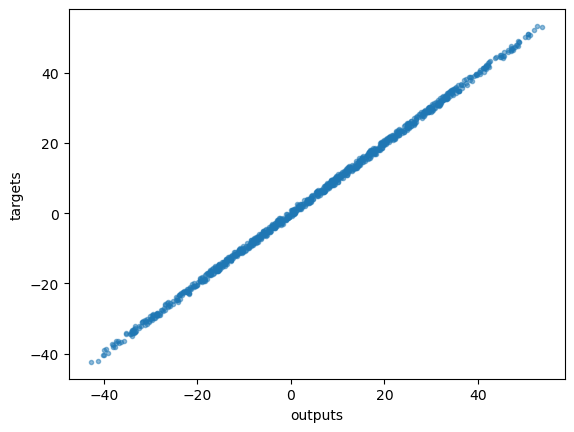

In [29]:
plt.scatter(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']), marker='.', alpha=0.5)
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()